Part 1:

Use the cifar10 dataset included with keras and construct a CNN to predict the image labels.\
Don't forget to visualize some images to understand the data.\
Train the network and visualize accuracy over epochs and check the output with outputing some predictions for visual comparison.


In [44]:
import keras

# load the cifar10 dataset from keras
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

In [45]:
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

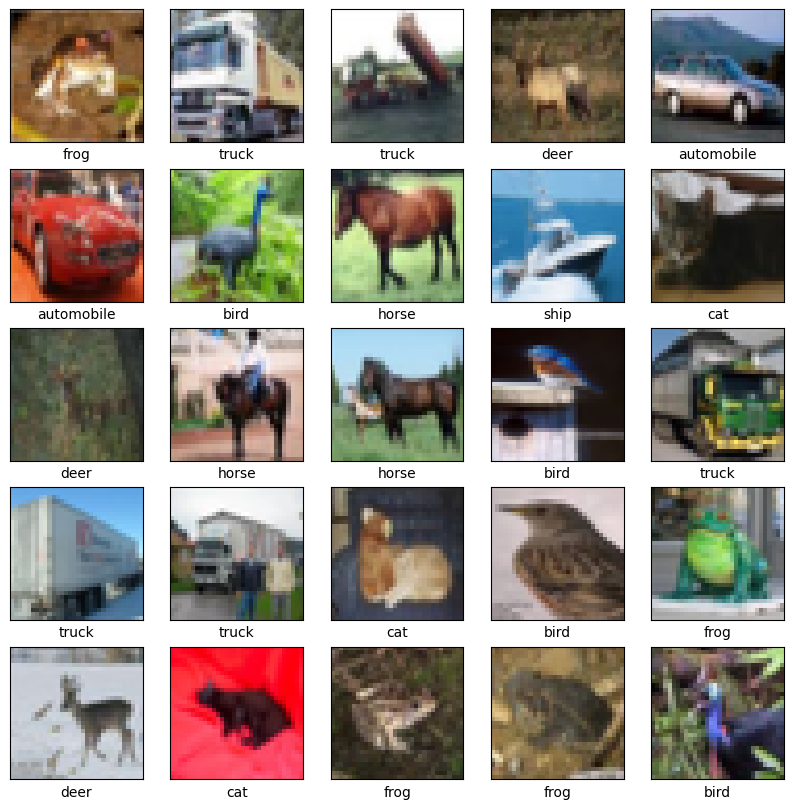

In [46]:
# visualize some of the data
import matplotlib.pyplot as plt
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

In [47]:
# construct a CNN to predict the image labels
from keras import datasets, layers, models

model = models.Sequential()

# added the convolutional layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# flatten
model.add(layers.Flatten())

# fully connected layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
# display the model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# compile the model
model.compile(optimizer='adam', loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])


In [50]:
# train the model
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.3737 - loss: 1.7003 - val_accuracy: 0.5745 - val_loss: 1.1931
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.5863 - loss: 1.1610 - val_accuracy: 0.6285 - val_loss: 1.0421
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.6528 - loss: 0.9817 - val_accuracy: 0.6722 - val_loss: 0.9451
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6965 - loss: 0.8699 - val_accuracy: 0.6705 - val_loss: 1.0020
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.7180 - loss: 0.8053 - val_accuracy: 0.6938 - val_loss: 0.9090
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.7428 - loss: 0.7331 - val_accuracy: 0.7014 - val_loss: 0.8706
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7607 - loss: 0.6812 - val_accuracy: 0.7005 - val_loss: 0.8769
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.7798 -

313/313 - 4s - 12ms/step - accuracy: 0.7149 - loss: 0.8930


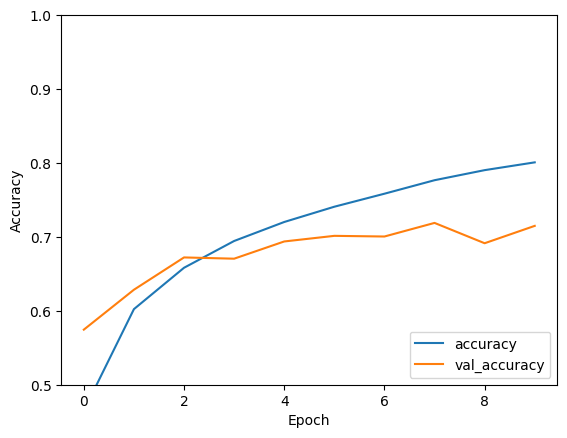

In [51]:
# evaluate the model's accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


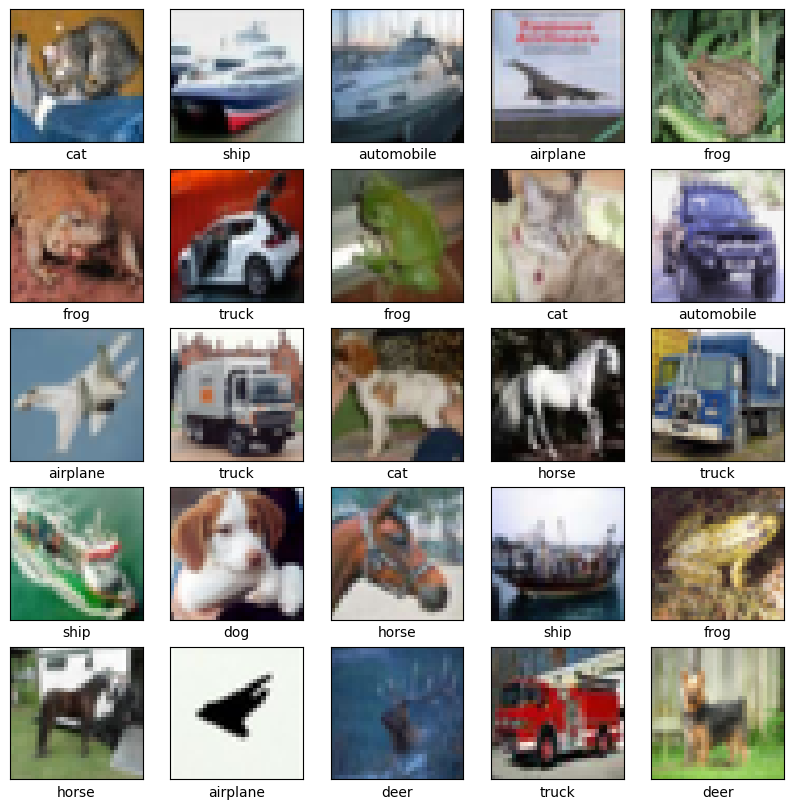

In [54]:
# visualize predictions
predictions = model.predict(x_test)
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    # The CIFAR labels happen to be arrays, which is why you need the extra index -_-
    plt.xlabel(class_names[np.argmax(predictions[i, :])])
plt.show()

Part 2:

Use the cifar100 dataset included with keras and repeat the experiment in Part 2.

Part3:

Use the Animal10 dataset in moodle to repeat the experiment. See also the Kaggle
page.\
a)

Download images to your computer and load the data organized as training and
testing data (use 20% for testing).\
Explore and visualize some of the data to gain a better understanding of the problem.\
You can use tensorflow's image_dataset_from_directory function and other standard functions to scale the dataset to the same input sizes, etc...\
b)

Explore the dataset.\
Visualize some images, check image sizes, number of images in each folder.\
c)

Perform operations to achieve a balanced dataset (use undersampling or data
augmentation).\
d)

Construct a Convolutional Neural Network to predict the correct label, and train it.\
Tune the structure and hyperparameters for best accuracy.\
Visualize accuracy over the training epochs.